# Energy Consumption EDA
Exploratory analysis of the UCI household power consumption dataset.
Run after completing ingest + feature pipeline.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet('../data/features/features.parquet')
print(f'Shape: {df.shape}')
df.head()

Shape: (33999, 13)


,consumption_kwh,lag_1h,lag_24h,lag_168h,rolling_mean_24h,rolling_mean_7d,rolling_std_24h,hour,day_of_week,month,is_weekend,is_holiday,target
datetime,,,,,,,,,,,,,
2006-12-23 17:00:00,5.452533,4.349100,1.496800,4.222889,2.934890,1.763946,0.990187,17,5,12,1,0,3.879400
2006-12-23 18:00:00,3.879400,5.452533,2.686967,3.632200,3.099713,1.771265,1.066674,18,5,12,1,0,4.117833
2006-12-23 19:00:00,4.117833,3.879400,3.938167,3.400233,3.149397,1.772736,1.074356,19,5,12,1,0,4.181400
2006-12-23 20:00:00,4.181400,4.117833,3.536067,3.268567,3.156883,1.777008,1.080699,20,5,12,1,0,3.288433
2006-12-23 21:00:00,3.288433,4.181400,4.548667,3.056467,3.183772,1.782441,1.098426,21,5,12,1,0,4.327933


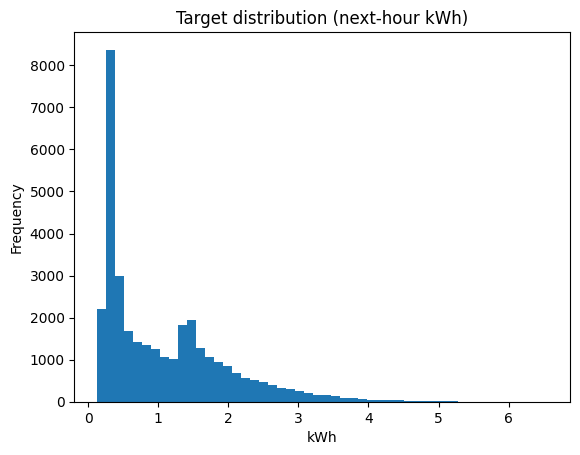

In [2]:
df['target'].plot(kind='hist', bins=50, title='Target distribution (next-hour kWh)')
plt.xlabel('kWh')
plt.show()

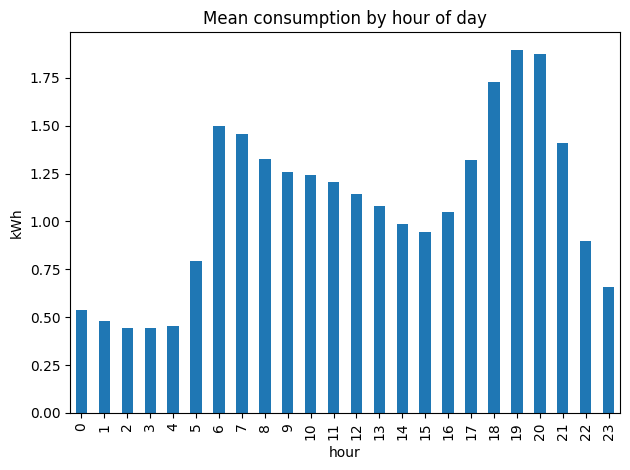

In [3]:
df.groupby('hour')['target'].mean().plot(
    kind='bar', title='Mean consumption by hour of day'
)
plt.ylabel('kWh')
plt.tight_layout()
plt.show()

In [4]:
df[['lag_1h', 'lag_24h', 'lag_168h', 'target']].corr().round(3)

,lag_1h,lag_24h,lag_168h,target
lag_1h,1.000,0.375,0.394,0.463
lag_24h,0.375,1.000,0.387,0.383
lag_168h,0.394,0.387,1.000,0.387
target,0.463,0.383,0.387,1.000
